## ALS Recommendation System for Student Projects

This notebook implements an Alternating Least Squares (ALS) recommendation system for student projects using **Custom ALS implementation** specifically designed for **explicit ratings** (1-5 scale).

## Setup
- **Items**: Project titles in Russian from data.xlsx
- **Interactions**: User ratings from artificial_profiles_scores.pkl
- **Library**: Custom ALS - designed for explicit ratings (1-5 scale)

In [1]:
import numpy as np
import pandas as pd
import pickle
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error

from als_explicit import ExplicitALS
import warnings
warnings.filterwarnings('ignore')

## Load Data

In [2]:
df = pd.read_excel('data.xlsx', header=0)
df = df.fillna('')
df.drop_duplicates(inplace=True)
print(f"Total projects: {len(df)}")

Total projects: 1250


In [3]:
df.head()

,title_rus,title_eng,goals,tasks,annotation,description,expectations,product_result,result_criterias,social_effect,commercial_effect
0,Исследование приоритетов и механизмов реализац...,Study of Priorities and Mechanisms for Impleme...,Целью проекта является эмпирическая проверка г...,1) Анализ повестки международных доноров\n2) А...,Работа международных фондов (доноров) должна п...,"Согласно определению международных фондов, про...",Аналитический отчет по избранным странам.\n\nС...,,,,
1,Антрополе - научно-популярный видео-подкаст о ...,Anthropole is a Popular Science Video Podcast ...,Выпустить и популяризовать 27 видео-подкастов ...,Снять и смонтировать подкасты;\nРазработать ст...,"\tАнтрополе - научно-популярный проект, в рамк...","Социальное знание близко и интересно обществу,...","Студенты получат опыт монтажа, продвижения и к...",Регулярный видео-подкаст (+экспедиционные филь...,Опубликованы 27 видео-подкастов о необычных со...,Популяризация социального знания должна привес...,Планируется в течение года выйти на окупаемост...
2,"Разработка, создание и ведение сайта, посвящен...","Design, Development and Implementation of a We...","Для того, чтобы получить более полное представ...",Подготовка технического задания для разработчи...,Художественное образование и творчество художн...,Тема обучения арабских художников в художестве...,"Навыки создания сайта (полный цикл, от подгото...","Создание сайта, посвященного истории арабских ...",Выполнение заданий руководителя проекта,Укрепление международных связей с художниками ...,
3,Перевод с английского языка коллективной моног...,Translation from English of the collective mon...,Результатом проекта станет качественный перево...,Результатом проекта станет качественный перево...,"Коллективная монография, авторы которой являют...","Коллективная монография, авторы которой являют...",Участники проекта приобретут новые знания в об...,Результатом проекта станет качественный перево...,Критериями достижения результата будет возможн...,,
4,Сеть военно-политических союзов в Евразии: баз...,Network of Military in Eurasia: a Database,Целью проекта является создание базы данных со...,1.\tОпределение методики включения союзов в ба...,Проект посвящен изучению сети военно-политичес...,Проект посвящен анализу истории существования ...,1.\tОбучение навыкам сбора и анализа данных 2....,База данных союзов 1815-2024 в Евразии.,Создание базы данных как минимум тысячи диадны...,,


In [4]:
with open('artificial_profiles_scores.pkl', 'rb') as f:
    interactions = pickle.load(f)

print("Interaction statistics per user:")
for user, ratings in interactions.items():
    valid_ratings = [r for r in ratings.values() if r is not None]
    print(f"  {user}: {len(ratings)} total, {len(valid_ratings)} rated")

Interaction statistics per user:
  digital_humanities_researcher: 125 total, 87 rated
  speech_ai_developer: 124 total, 38 rated
  academic_researcher_hse_gcii: 125 total, 105 rated
  crm_travel_tech_analyst: 124 total, 38 rated
  rtb_bid_optimization_specialist: 124 total, 6 rated
  general_linguistics_enthusiast: 125 total, 74 rated
  monetary_policy_researcher: 125 total, 38 rated
  computer_vision_researcher: 125 total, 46 rated


## Build User-Item Matrix

In [5]:
project_titles = df['title_rus'].tolist()
user_ids = list(interactions.keys())

print(f"Number of users: {len(user_ids)}")
print(f"Number of projects: {len(project_titles)}")

Number of users: 8
Number of projects: 1250


In [6]:
num_users = len(user_ids)
num_items = len(project_titles)

user_to_idx = {user: idx for idx, user in enumerate(user_ids)}
item_to_idx = {item: idx for idx, item in enumerate(project_titles)}

row_indices = []
col_indices = []
ratings = []

for user, user_ratings in interactions.items():
    user_idx = user_to_idx[user]
    for project_title, rating in user_ratings.items():
        if rating is not None and rating > 2 and project_title in item_to_idx:
            item_idx = item_to_idx[project_title]
            row_indices.append(user_idx)
            col_indices.append(item_idx)
            ratings.append(rating)

rating_matrix = csr_matrix((ratings, (row_indices, col_indices)), 
                           shape=(num_users, num_items))

print(f"Rating matrix shape: {rating_matrix.shape}")
print(f"Number of ratings: {len(ratings)}")
print(f"Sparsity: {len(ratings) / (num_users * num_items) * 100:.2f}%")

Rating matrix shape: (8, 1250)
Number of ratings: 202
Sparsity: 2.02%


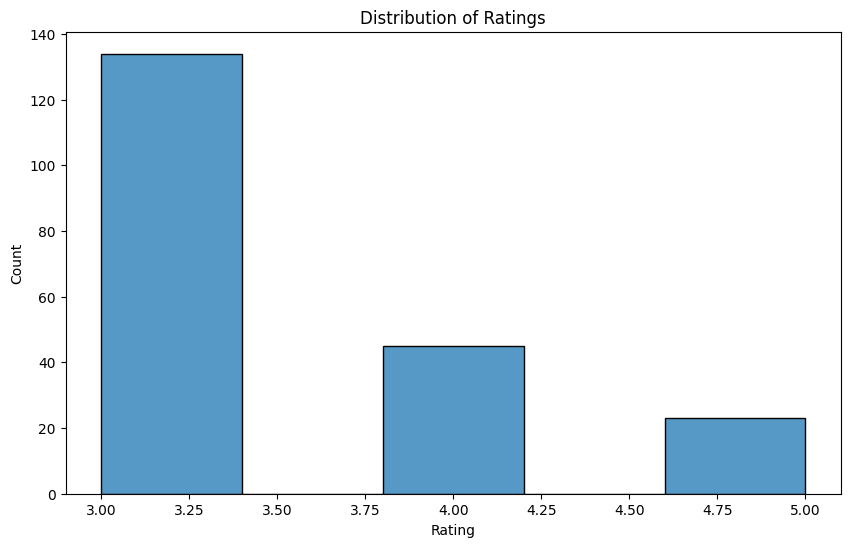

Rating statistics:
  Mean: 3.45
  Std: 0.69
  Min: 3
  Max: 5


In [7]:
rating_values = [r for r in ratings]
plt.figure(figsize=(10, 6))
sns.histplot(rating_values, bins=5, kde=False)
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

print(f"Rating statistics:")
print(f"  Mean: {np.mean(rating_values):.2f}")
print(f"  Std: {np.std(rating_values):.2f}")
print(f"  Min: {np.min(rating_values)}")
print(f"  Max: {np.max(rating_values)}")

## Split Data into Train and Test Sets

In [8]:
from sklearn.model_selection import train_test_split

rows, cols = rating_matrix.nonzero()
n_ratings = len(rows)

rating_indices = np.arange(n_ratings)

train_indices, test_indices = train_test_split(
    rating_indices, 
    test_size=0.2, 
    random_state=42,
    stratify=rows
)

train_rows = rows[train_indices]
train_cols = cols[train_indices]
train_ratings_data = np.array([rating_matrix[train_rows[i], train_cols[i]] for i in range(len(train_indices))])

test_rows = rows[test_indices]
test_cols = cols[test_indices]
test_ratings_data = np.array([rating_matrix[test_rows[i], test_cols[i]] for i in range(len(test_indices))])

train_matrix = csr_matrix((train_ratings_data, (train_rows, train_cols)), 
                         shape=(num_users, num_items))

print(f"Original ratings: {n_ratings}")
print(f"Training ratings: {len(train_indices)} ({len(train_indices)/n_ratings*100:.1f}%)")
print(f"Test ratings: {len(test_indices)} ({len(test_indices)/n_ratings*100:.1f}%)")

train_users = set(train_rows)
test_users = set(test_rows)
print(f"\nUsers in training set: {len(train_users)}")
print(f"Users in test set: {len(test_users)}")

Original ratings: 202
Training ratings: 161 (79.7%)
Test ratings: 41 (20.3%)

Users in training set: 8
Users in test set: 8


In [9]:
model = ExplicitALS(
    n_factors=5,
    n_iterations=64,
    user_reg=5,
    item_reg=5,
    early_stopping_rounds=4,
    random_state=42
)

print("Custom ALS model initialized with anti-overfitting settings:")
print(f"  - Factors: {model.n_factors}")
print(f"  - Max iterations: {model.n_iterations}")
print(f"  - User regularization: {model.user_reg}")
print(f"  - Item regularization: {model.item_reg}")
print(f"  - Early stopping rounds: {model.early_stopping_rounds}")

Custom ALS model initialized with anti-overfitting settings:
  - Factors: 5
  - Max iterations: 64
  - User regularization: 5
  - Item regularization: 5
  - Early stopping rounds: 4


In [10]:
final_train_indices, val_indices = train_test_split(
    np.arange(len(train_indices)),
    test_size=0.2, 
    random_state=42,
    stratify=train_rows
)

final_train_rows = train_rows[final_train_indices]
final_train_cols = train_cols[final_train_indices]
final_train_ratings_data = np.array([rating_matrix[final_train_rows[i], final_train_cols[i]] 
                                    for i in range(len(final_train_indices))])

val_rows = train_rows[val_indices]
val_cols = train_cols[val_indices]
val_ratings_data = np.array([rating_matrix[val_rows[i], val_cols[i]] 
                           for i in range(len(val_indices))])

final_train_matrix = csr_matrix((final_train_ratings_data, (final_train_rows, final_train_cols)), 
                                shape=(num_users, num_items))
val_matrix = csr_matrix((val_ratings_data, (val_rows, val_cols)), 
                       shape=(num_users, num_items))

print(f"Final training data: {len(final_train_indices)} ratings")
print(f"Validation data: {len(val_indices)} ratings")
print(f"Test data: {len(test_indices)} ratings")

print("\nUser distribution across splits:")
for user_idx in range(num_users):
    train_count = np.sum(final_train_rows == user_idx)
    val_count = np.sum(val_rows == user_idx)
    test_count = np.sum(test_rows == user_idx)
    print(f"  {user_ids[user_idx]}: Train={train_count}, Val={val_count}, Test={test_count}")

Final training data: 128 ratings
Validation data: 33 ratings
Test data: 41 ratings

User distribution across splits:
  digital_humanities_researcher: Train=26, Val=7, Test=8
  speech_ai_developer: Train=6, Val=2, Test=2
  academic_researcher_hse_gcii: Train=39, Val=10, Test=12
  crm_travel_tech_analyst: Train=13, Val=3, Test=4
  rtb_bid_optimization_specialist: Train=2, Val=1, Test=1
  general_linguistics_enthusiast: Train=18, Val=4, Test=6
  monetary_policy_researcher: Train=7, Val=2, Test=2
  computer_vision_researcher: Train=17, Val=4, Test=6


In [11]:
print("Training Custom ALS model with early stopping...")
model.fit(final_train_matrix, validation_matrix=val_matrix)

print("\nTraining completed!")
print(f"Model user factors shape: {model.user_factors.shape}")
print(f"Model item factors shape: {model.item_factors.shape}")

print(f"\nTraining stopped after {len(model.training_history)} iterations")

Training Custom ALS model with early stopping...
Iteration 0, Train MSE: 11.6351, Val MSE: 12.6616
Iteration 2, Train MSE: 1.7965, Val MSE: 13.0670
Iteration 4, Train MSE: 1.4798, Val MSE: 13.0230
Early stopping at iteration 4
Training completed after 5 iterations

Training completed!
Model user factors shape: (8, 5)
Model item factors shape: (1250, 5)

Training stopped after 5 iterations


In [12]:
def predict_for_pairs(model, rows, cols):
    """Predict ratings for specific user-item pairs"""
    predictions = np.zeros(len(rows))
    for idx, (u, i) in enumerate(zip(rows, cols)):
        predictions[idx] = model.user_factors[u] @ model.item_factors[i]
    return predictions

train_predictions = predict_for_pairs(model, final_train_rows, final_train_cols)
train_mse = mean_squared_error(final_train_ratings_data, train_predictions)
train_rmse = np.sqrt(train_mse)

print("Training Set Performance:")
print(f"  MSE: {train_mse:.4f}")
print(f"  RMSE: {train_rmse:.4f}")

val_predictions = predict_for_pairs(model, val_rows, val_cols)
val_mse = mean_squared_error(val_ratings_data, val_predictions)
val_rmse = np.sqrt(val_mse)

print("\nValidation Set Performance:")
print(f"  MSE: {val_mse:.4f}")
print(f"  RMSE: {val_rmse:.4f}")

test_predictions = predict_for_pairs(model, test_rows, test_cols)
test_mse = mean_squared_error(test_ratings_data, test_predictions)
test_rmse = np.sqrt(test_mse)

print("\nTest Set Performance:")
print(f"  MSE: {test_mse:.4f}")
print(f"  RMSE: {test_rmse:.4f}")

print(f"\nOverfitting Analysis:")
print(f"  Val/Train RMSE ratio: {val_rmse/train_rmse:.2f}")
print(f"  Test/Train RMSE ratio: {test_rmse/train_rmse:.2f}")
print(f"  Test/Val RMSE ratio: {test_rmse/val_rmse:.2f}")

if test_rmse/train_rmse < 1.5:
    print("\n✓ Model generalizes well (low overfitting)")
elif test_rmse/train_rmse < 2.0:
    print("\n⚠ Model shows moderate overfitting")
else:
    print("\n✗ Model shows significant overfitting")

Training Set Performance:
  MSE: 11.6351
  RMSE: 3.4110

Validation Set Performance:
  MSE: 12.6616
  RMSE: 3.5583

Test Set Performance:
  MSE: 12.4659
  RMSE: 3.5307

Overfitting Analysis:
  Val/Train RMSE ratio: 1.04
  Test/Train RMSE ratio: 1.04
  Test/Val RMSE ratio: 0.99

✓ Model generalizes well (low overfitting)


## Generate Recommendations

In [13]:
rated_items = {}
train_matrix_rows, train_matrix_cols = train_matrix.nonzero()
for u, i in zip(train_matrix_rows, train_matrix_cols):
    if u not in rated_items:
        rated_items[u] = set()
    rated_items[u].add(i)

model.rated_items = rated_items

print("Rated items from training set stored for each user:")
for user_idx, items in rated_items.items():
    print(f"  User {user_ids[user_idx]}: {len(items)} rated projects")

Rated items from training set stored for each user:
  User digital_humanities_researcher: 33 rated projects
  User speech_ai_developer: 8 rated projects
  User academic_researcher_hse_gcii: 49 rated projects
  User crm_travel_tech_analyst: 16 rated projects
  User rtb_bid_optimization_specialist: 3 rated projects
  User general_linguistics_enthusiast: 22 rated projects
  User monetary_policy_researcher: 9 rated projects
  User computer_vision_researcher: 21 rated projects


In [14]:
for user_idx in rated_items:
    recs = model.recommend(user_idx=user_idx, n_recommendations=5)
    for rec in recs:
        print(f"{user_ids[user_idx]}: {project_titles[rec[0]]}, {rec[1]}")

digital_humanities_researcher: "Переход от поиска источников к готовым ответам: влияние ИИ (chat GPT) на пользователей через анализ медиаконтента"., 0.06525781142223325
digital_humanities_researcher: Витгенштейн о границах логики языка, 0.056062020570666296
digital_humanities_researcher: Коллективные онлайн-реакции на социальное насилие: исследование дискурса и эмоций на имиджбордах, 0.056062020570666296
digital_humanities_researcher: Анализ, описание и обработка электронных документов кадровых практик Всероссийского конкурса "Лучшие кадровые практики и инициативы в системе государственного и муниципального управления", 0.05006456492694478
digital_humanities_researcher: Мультиагентная интеллектуальная обучающая система для изучения JavaScript, 0.04484961645653303
speech_ai_developer: Разработка системы классификации степени тяжести афазии на основе анализа речевых сигналов, 0.02820403912377009
speech_ai_developer: ТехноПоиск: Внутренняя система семантического поиска по технической доку

# Test different regularization values with fixed architecture

In [15]:
regularization_values = [0.1, 0.5, 1.0, 2.0, 5.0, 10, 100, 1000]
results = []

print("Testing different regularization values...")
for reg_value in regularization_values:
    print(f"\nTraining with regularization={reg_value}...")
    
    test_model = ExplicitALS(
        n_factors=5,
        n_iterations=64,
        user_reg=reg_value,
        item_reg=reg_value,
        early_stopping_rounds=4,
        random_state=42
    )
    
    test_model.fit(final_train_matrix, validation_matrix=val_matrix)
    
    train_preds = predict_for_pairs(test_model, final_train_rows, final_train_cols)
    train_mse = mean_squared_error(final_train_ratings_data, train_preds)
    
    val_preds = predict_for_pairs(test_model, val_rows, val_cols)
    val_mse = mean_squared_error(val_ratings_data, val_preds)
    
    test_preds = predict_for_pairs(test_model, test_rows, test_cols)
    test_mse = mean_squared_error(test_ratings_data, test_preds)
    
    results.append({
        'regularization': reg_value,
        'train_mse': train_mse,
        'train_rmse': np.sqrt(train_mse),
        'val_mse': val_mse,
        'val_rmse': np.sqrt(val_mse),
        'test_mse': test_mse,
        'test_rmse': np.sqrt(test_mse),
        'n_iterations': len(test_model.training_history),
        'test_rmse/train_rmse': np.sqrt(test_mse) / np.sqrt(train_mse)
    })

results_df = pd.DataFrame(results)

Testing different regularization values...

Training with regularization=0.1...
Iteration 0, Train MSE: 0.0003, Val MSE: 13.2938
Iteration 2, Train MSE: 0.0002, Val MSE: 13.3795
Iteration 4, Train MSE: 0.0002, Val MSE: 13.4532
Early stopping at iteration 4
Training completed after 5 iterations

Training with regularization=0.5...
Iteration 0, Train MSE: 0.2364, Val MSE: 12.9643
Iteration 2, Train MSE: 0.0483, Val MSE: 13.0263
Iteration 4, Train MSE: 0.0317, Val MSE: 13.0837
Early stopping at iteration 4
Training completed after 5 iterations

Training with regularization=1.0...
Iteration 0, Train MSE: 1.7763, Val MSE: 12.9296
Iteration 2, Train MSE: 0.1968, Val MSE: 13.0662
Iteration 4, Train MSE: 0.1147, Val MSE: 13.1224
Early stopping at iteration 4
Training completed after 5 iterations

Training with regularization=2.0...
Iteration 0, Train MSE: 6.7902, Val MSE: 12.8108
Iteration 2, Train MSE: 0.3527, Val MSE: 13.0757
Iteration 4, Train MSE: 0.2714, Val MSE: 13.1295
Early stopping at

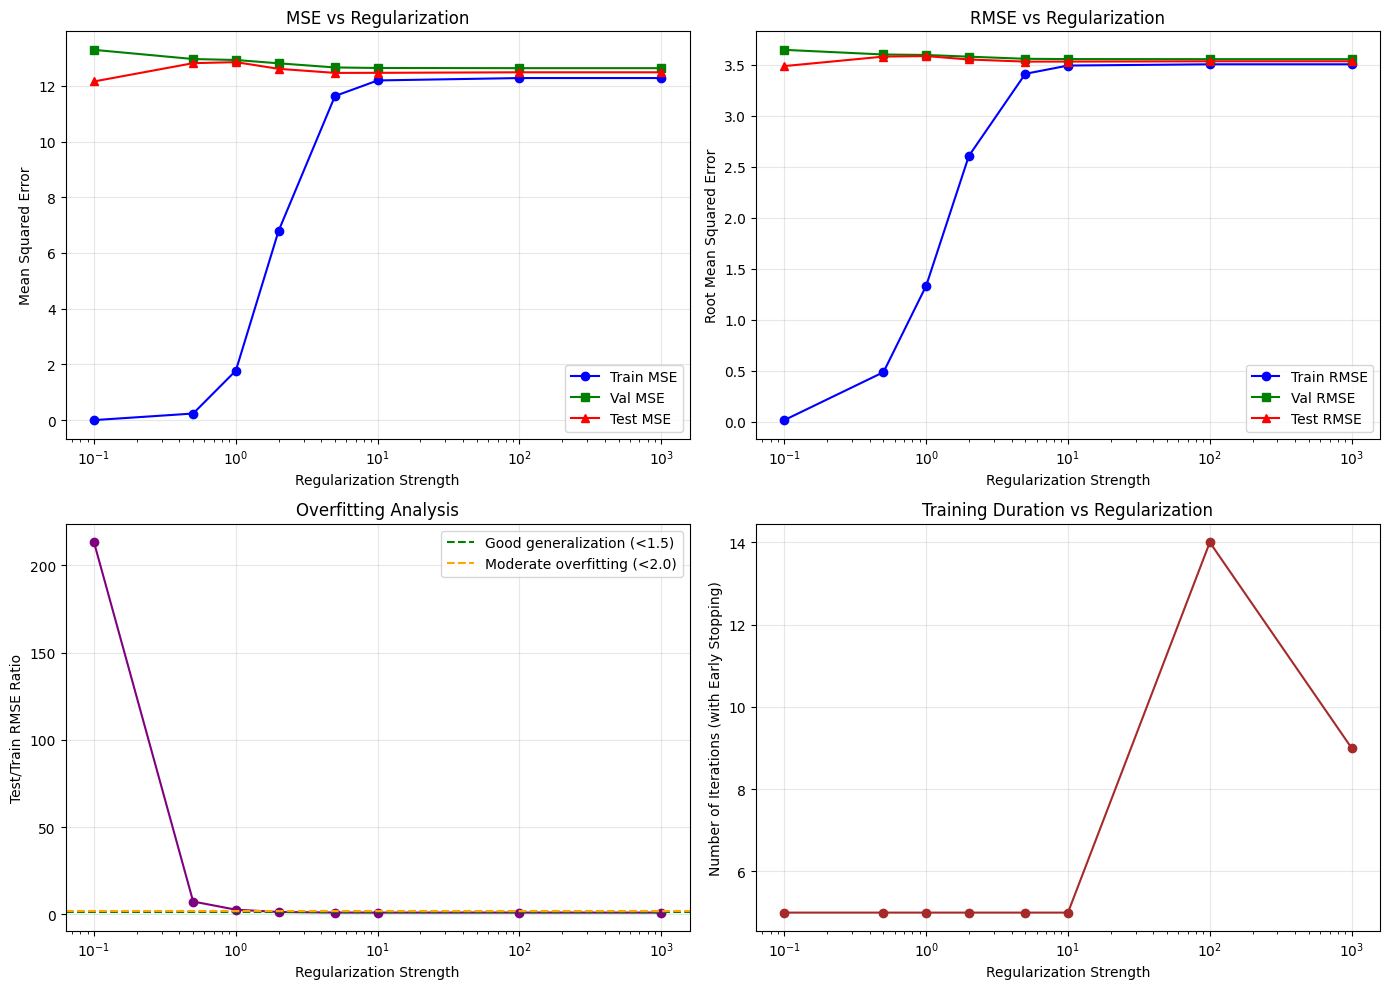

Best model based on test performance:
  Regularization: 100.0
  Test RMSE: 3.5338
  Overfitting ratio: 1.01
  ✓ Excellent generalization


In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(results_df['regularization'], results_df['train_mse'], 'o-', label='Train MSE', color='blue')
axes[0,0].plot(results_df['regularization'], results_df['val_mse'], 's-', label='Val MSE', color='green')
axes[0,0].plot(results_df['regularization'], results_df['test_mse'], '^-', label='Test MSE', color='red')
axes[0,0].set_xlabel('Regularization Strength')
axes[0,0].set_ylabel('Mean Squared Error')
axes[0,0].set_title('MSE vs Regularization')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)
axes[0,0].set_xscale('log')

axes[0,1].plot(results_df['regularization'], results_df['train_rmse'], 'o-', label='Train RMSE', color='blue')
axes[0,1].plot(results_df['regularization'], results_df['val_rmse'], 's-', label='Val RMSE', color='green')
axes[0,1].plot(results_df['regularization'], results_df['test_rmse'], '^-', label='Test RMSE', color='red')
axes[0,1].set_xlabel('Regularization Strength')
axes[0,1].set_ylabel('Root Mean Squared Error')
axes[0,1].set_title('RMSE vs Regularization')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)
axes[0,1].set_xscale('log')

overfitting_ratio = results_df['test_rmse'] / results_df['train_rmse']
axes[1,0].plot(results_df['regularization'], overfitting_ratio, 'o-', color='purple')
axes[1,0].axhline(y=1.5, color='green', linestyle='--', label='Good generalization (<1.5)')
axes[1,0].axhline(y=2.0, color='orange', linestyle='--', label='Moderate overfitting (<2.0)')
axes[1,0].set_xlabel('Regularization Strength')
axes[1,0].set_ylabel('Test/Train RMSE Ratio')
axes[1,0].set_title('Overfitting Analysis')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)
axes[1,0].set_xscale('log')

axes[1,1].plot(results_df['regularization'], results_df['n_iterations'], 'o-', color='brown')
axes[1,1].set_xlabel('Regularization Strength')
axes[1,1].set_ylabel('Number of Iterations (with Early Stopping)')
axes[1,1].set_title('Training Duration vs Regularization')
axes[1,1].grid(True, alpha=0.3)
axes[1,1].set_xscale('log')

plt.tight_layout()
plt.show()

best_idx = results_df['test_rmse/train_rmse'].idxmin()
best_reg = results_df.loc[best_idx, 'regularization']
best_test_rmse = results_df.loc[best_idx, 'test_rmse']
best_ratio = overfitting_ratio[best_idx]

print(f"Best model based on test performance:")
print(f"  Regularization: {best_reg}")
print(f"  Test RMSE: {best_test_rmse:.4f}")
print(f"  Overfitting ratio: {best_ratio:.2f}")

if best_ratio < 1.5:
    print("  ✓ Excellent generalization")
elif best_ratio < 2.0:
    print("  ⚠ Acceptable generalization")
else:
    print("  ✗ Poor generalization")

## Hyperparameter Tuning with Train/Test Evaluation

In [17]:
factors_to_test = [5, 10, 20, 30]
results = []

print("Testing different numbers of factors with train/test evaluation...")
for n_factors in factors_to_test:
    print(f"\nTraining with {n_factors} factors...")
    
    test_model = ExplicitALS(
        n_factors=n_factors,
        n_iterations=64,
        user_reg=5,
        item_reg=5,
        early_stopping_rounds=4,
        random_state=42
    )
    
    test_model.fit(train_matrix)
    
    train_preds = predict_for_pairs(test_model, train_rows, train_cols)
    train_mse = mean_squared_error(train_ratings_data, train_preds)
    
    test_preds = predict_for_pairs(test_model, test_rows, test_cols)
    test_mse = mean_squared_error(test_ratings_data, test_preds)
    
    results.append({
        'n_factors': n_factors,
        'train_mse': train_mse,
        'train_rmse': np.sqrt(train_mse),
        'test_mse': test_mse,
        'test_rmse': np.sqrt(test_mse)
    })
    
    print(f"  Train MSE: {train_mse:.4f}, RMSE: {np.sqrt(train_mse):.4f}")
    print(f"  Test MSE: {test_mse:.4f}, RMSE: {np.sqrt(test_mse):.4f}")

results_df = pd.DataFrame(results)

Testing different numbers of factors with train/test evaluation...

Training with 5 factors...
Iteration 0, Train MSE: 11.6316
Iteration 5, Train MSE: 1.2312
Iteration 10, Train MSE: 1.2128
Iteration 15, Train MSE: 1.2098
Iteration 20, Train MSE: 1.2098
Iteration 25, Train MSE: 1.2103
Iteration 30, Train MSE: 1.2109
Iteration 35, Train MSE: 1.2113
Iteration 40, Train MSE: 1.2116
Iteration 45, Train MSE: 1.2118
Iteration 50, Train MSE: 1.2121
Iteration 55, Train MSE: 1.2122
Iteration 60, Train MSE: 1.2124
Iteration 63, Train MSE: 1.2125
Training completed after 64 iterations
  Train MSE: 1.2125, RMSE: 1.1011
  Test MSE: 11.2234, RMSE: 3.3501

Training with 10 factors...
Iteration 0, Train MSE: 10.8473
Iteration 5, Train MSE: 1.2207
Iteration 10, Train MSE: 1.2145
Iteration 15, Train MSE: 1.2128
Iteration 20, Train MSE: 1.2127
Iteration 25, Train MSE: 1.2131
Iteration 30, Train MSE: 1.2136
Iteration 35, Train MSE: 1.2140
Iteration 40, Train MSE: 1.2143
Iteration 45, Train MSE: 1.2146
Ite

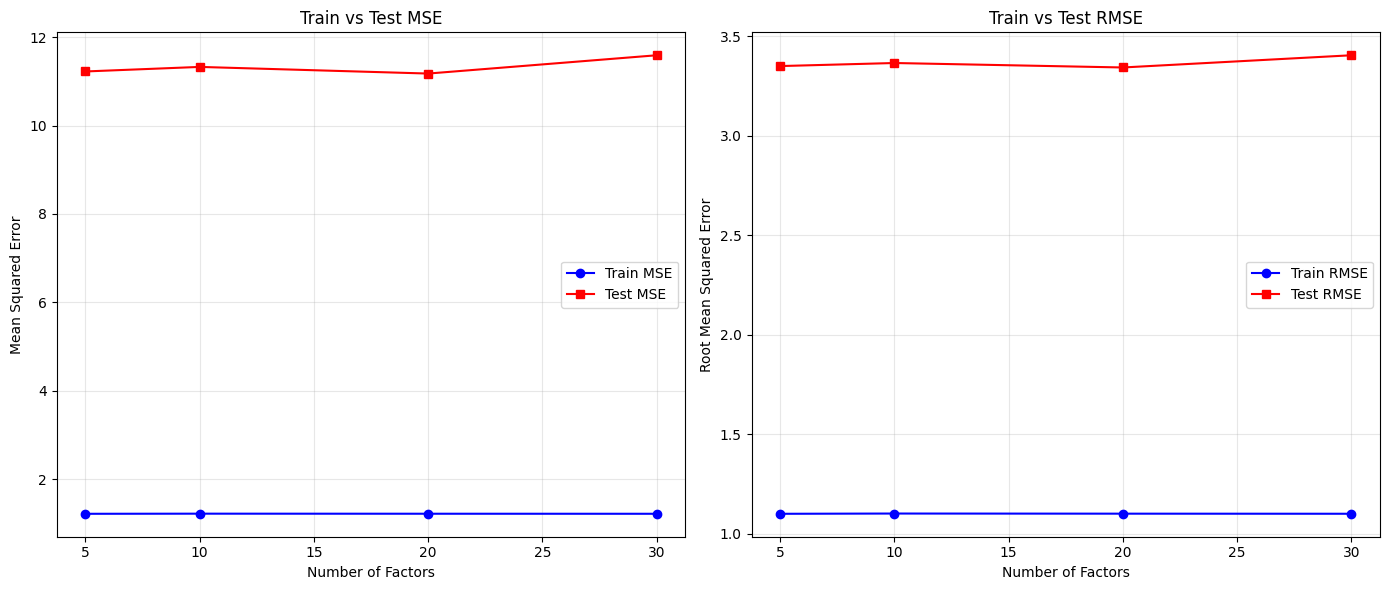

Best model based on test performance:
  Number of factors: 20
  Test RMSE: 3.3431


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].plot(results_df['n_factors'], results_df['train_mse'], 'o-', label='Train MSE', color='blue')
axes[0].plot(results_df['n_factors'], results_df['test_mse'], 's-', label='Test MSE', color='red')
axes[0].set_xlabel('Number of Factors')
axes[0].set_ylabel('Mean Squared Error')
axes[0].set_title('Train vs Test MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(results_df['n_factors'], results_df['train_rmse'], 'o-', label='Train RMSE', color='blue')
axes[1].plot(results_df['n_factors'], results_df['test_rmse'], 's-', label='Test RMSE', color='red')
axes[1].set_xlabel('Number of Factors')
axes[1].set_ylabel('Root Mean Squared Error')
axes[1].set_title('Train vs Test RMSE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_idx = results_df['test_rmse'].idxmin()
best_n_factors = results_df.loc[best_idx, 'n_factors']
best_test_rmse = results_df.loc[best_idx, 'test_rmse']

print(f"Best model based on test performance:")
print(f"  Number of factors: {best_n_factors}")
print(f"  Test RMSE: {best_test_rmse:.4f}")

## Save Model for Future Use

In [ ]:
model_data = {
    'user_factors': model.user_factors,
    'item_factors': model.item_factors,
    'user_ids': user_ids,
    'item_ids': project_titles,
    'rated_items': rated_items,
    'train_data': {
        'rows': final_train_rows,
        'cols': final_train_cols,
        'ratings': final_train_ratings_data
    },
    'val_data': {
        'rows': val_rows,
        'cols': val_cols,
        'ratings': val_ratings_data
    },
    'test_data': {
        'rows': test_rows,
        'cols': test_cols,
        'ratings': test_ratings_data
    },
    'model_params': {
        'n_factors': model.n_factors,
        'n_iterations': model.n_iterations,
        'user_reg': model.user_reg,
        'item_reg': model.item_reg,
        'early_stopping_rounds': model.early_stopping_rounds,
        'random_state': model.random_state
    },
    'performance': {
        'train_mse': train_mse,
        'train_rmse': train_rmse,
        'val_mse': val_mse,
        'val_rmse': val_rmse,
        'test_mse': test_mse,
        'test_rmse': test_rmse,
        'overfitting_ratio': test_rmse/train_rmse
    },
    'training_history': model.training_history
}

with open('custom_als_model.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print("Custom ALS model with anti-overfitting saved to custom_als_model.pkl")

Custom ALS model with anti-overfitting saved to custom_als_model.pkl
